In [1]:
import sys
from dotenv import load_dotenv
import os

load_dotenv(override=True)

if "../app/" not in sys.path:
    sys.path.append("../app/")

print(sys.path)

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/ryanwtsai/repos/lms-ai-agent/notebooks/venv/lib/python3.12/site-packages', '../app/']


In [2]:
collection_name = "test"

In [3]:
from pathlib import Path

files_dict = {}
file_exts = [".txt", ".html", ".vtt", ".md", ".pdf", ".pptx", ".ipynb"]
file_exts = [".txt", ".vtt", ".md", ".pdf", ".pptx", ".ipynb"]
for ext in file_exts:
    files_dict[ext] = list(Path(".").glob(f"Content/**/*{ext}"))

files = [v[0] for k, v in files_dict.items() if len(v) > 0]
files

[PosixPath('Content/AWS introduction/connecting-aws-ec2-with-session-manager.md'),
 PosixPath('Content/Excel Fundamental (self-paced)/Excel.pdf'),
 PosixPath('Content/AWS introduction/AWS VPC & Networking.pptx'),
 PosixPath('Content/Data wrangling with Python/Class 7 - Advanced Pandas_Solutions.ipynb')]

In [4]:
from haystack_utilities.pipelines import indexing_pipeline_lambda

# sentence-transformers/all-mpnet-base-v2
# Max tokens = 384
# Roughly 288 words (3 words = 4 tokens)
# 'fixed250'
splitting_options = {
    "split_strategy": "fixed",
    "split_by": "word",
    "split_length": 250,
    "split_overlap": 50,
    "split_threshold": 30,
    "respect_sentence_boundary": True
}

skip_cleaner=True
add_tagger=True
index_pipe = indexing_pipeline_lambda.build_indexing_pipeline(collection_name, splitting_options, skip_cleaner=skip_cleaner, add_tagger=add_tagger, max_content_len_chars=65535, drop_old=True)

Some secret values are not encrypted. Please use `Secret` class to encrypt them. The best way to implement it is to use `Secret.from_env` to load from environment variables. For example:
from haystack.utils import Secret
token = Secret.from_env('YOUR_TOKEN_ENV_VAR_NAME')


In [ ]:
index_pipe.show()

In [ ]:
# index_results = index_pipe.run({"file_type_router": {"sources": files}}, include_outputs_from={"file_type_router", "txt_converter", "pdf_converter", "pptx_converter", "ipynb_converter", "document_joiner", "metadata_cleaner"})
index_results = index_pipe.run({"file_type_router": {"sources": files}}, include_outputs_from={"file_type_router", "txt_converter", "pdf_converter", "pptx_converter", "ipynb_converter", "converter_document_joiner", "metadata_router", "tagger", "ipynb_tagger", "metadata_document_joiner", "metadata_cleaner"})
index_results

No abbreviations file found for en. Using default abbreviations.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

{'writer': {'documents_written': 34},
 'file_type_router': {'text/.*': [PosixPath('Content/AWS introduction/connecting-aws-ec2-with-session-manager.md')],
  'application/pdf': [PosixPath('Content/Excel Fundamental (self-paced)/Excel.pdf')],
  'application/vnd.openxmlformats-officedocument.presentationml.presentation': [PosixPath('Content/AWS introduction/AWS VPC & Networking.pptx')],
  'application/x-ipynb\\+json': [PosixPath('Content/Data wrangling with Python/Class 7 - Advanced Pandas_Solutions.ipynb')]},
 'txt_converter': {'documents': [Document(id=0bf4210a85e44a670e8908b91f5099b4e0ce5c8500a80698c9208cd23798059e, content: '# Connecting AWS EC2 with Session Manager
   
   <img src='https://s3.amazonaws.com/weclouddata/images/log...', meta: {'file_path': 'connecting-aws-ec2-with-session-manager.md'})]},
 'pdf_converter': {'documents': [Document(id=4bfa1f54cd3b428a234cef612474289c6965cc6356677f7b855be7978fdf3345, content: '             Excel Fundamentals
                for Business In

In [27]:
print("file_type_router:")
print(index_results["file_type_router"])
print(f"\n{"-"*50}\n")

for file_type in ["txt", "pdf", "pptx", "ipynb"]:
    print(f"{file_type}_converter:")
    for doc in index_results[f"{file_type}_converter"]["documents"]:
        print(doc.meta["file_path"])
    print(f"\n{"-"*50}\n")

print("converter_document_joiner:")
for doc in index_results.get("converter_document_joiner", {}).get("documents", []):
    print(doc.meta["file_path"])
print(f"\n{"-"*50}\n")

print("metadata_router:")
for k, v in index_results.get("metadata_router", {}).items():
    print(f"{k} (num_docs = {len(v)}): {[doc.meta["metadata"]["file_type"] for doc in v]}")
print(f"\n{"-"*50}\n")

print(f"ipynb_tagger (num_docs = {len(index_results.get("ipynb_tagger", {}).get("documents", []))}): {[doc.meta["metadata"]["file_type"] for doc in index_results.get("ipynb_tagger", {}).get("documents", [])]}")
print(f"tagger (num_docs = {len(index_results.get("tagger", {}).get("documents", []))}): {[doc.meta["metadata"]["file_type"] for doc in index_results.get("tagger", {}).get("documents", [])]}")
print(f"\n{"-"*50}\n")

counter = 0
for doc in index_results["metadata_cleaner"]["documents"]:
    if len(doc.content) > 65535:
        # print(doc.meta)
        with open("long_text.txt", "w") as file_obj:
            file_obj.write(doc.content)
    # if doc.meta["metadata"]["title"] == 'Exercise_Part_3_Pandas Index.html':
    #     # print(doc.meta["metadata"])
    #     counter += 1
    #     print(counter)
    #     # print(len(doc.content))

file_type_router:
{'text/.*': [PosixPath('Content/AWS introduction/connecting-aws-ec2-with-session-manager.md')], 'application/pdf': [PosixPath('Content/Excel Fundamental (self-paced)/Excel.pdf')], 'application/vnd.openxmlformats-officedocument.presentationml.presentation': [PosixPath('Content/AWS introduction/AWS VPC & Networking.pptx')], 'application/x-ipynb\\+json': [PosixPath('Content/Data wrangling with Python/Class 7 - Advanced Pandas_Solutions.ipynb')]}

--------------------------------------------------

txt_converter:
connecting-aws-ec2-with-session-manager.md

--------------------------------------------------

pdf_converter:
Excel.pdf

--------------------------------------------------

pptx_converter:
AWS VPC & Networking.pptx

--------------------------------------------------

ipynb_converter:
Class 7 - Advanced Pandas_Solutions.ipynb

--------------------------------------------------

converter_document_joiner:

--------------------------------------------------

metada

In [57]:
if "splitter" in index_results.keys():
    comp_name = "splitter"
elif "embedder" in index_results.keys():
    comp_name = "embedder"
elif "metadata_cleaner" in index_results.keys():
    comp_name = "metadata_cleaner"
else:
    comp_name = None

if comp_name:
    lengths = [len(doc.content) for doc in index_results[comp_name]["documents"]]
    print(f"Max len char = {max(lengths)}")
    print(f"Min len char = {min(lengths)}")



Max len char = 5884
Min len char = 590


(array([ 1., 11., 11.,  7.,  1.,  2.,  0.,  0.,  0.,  1.]),
 array([ 590. , 1119.4, 1648.8, 2178.2, 2707.6, 3237. , 3766.4, 4295.8,
        4825.2, 5354.6, 5884. ]),
 <BarContainer object of 10 artists>)

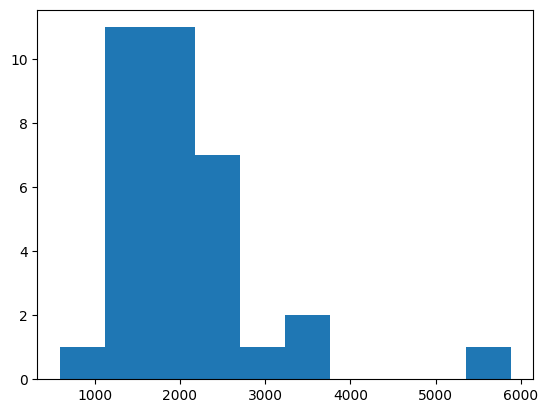

In [58]:
import matplotlib.pyplot as plt

lengths = [l for l in lengths if l < 65535]

plt.hist(lengths)

In [59]:
from haystack_utilities.tools import MilvusContextManager

with MilvusContextManager() as client:
    print(client.list_collections())
    # client.drop_collection('ipynb_skipclean_fixed250_tag30_prompt15')
    # client.drop_collection('ipynb_skipclean_fixed250_tag30_prompt15')
    print(client.list_collections())

['ipynb_test', 'pptx_fixed250_tag30_prompt14', 'test', 'ipynb_skipclean_fixed250_tag30_prompt17_all_ids', 'ipynb_skipclean_fixed250_tag30_prompt18']
['ipynb_test', 'pptx_fixed250_tag30_prompt14', 'test', 'ipynb_skipclean_fixed250_tag30_prompt17_all_ids', 'ipynb_skipclean_fixed250_tag30_prompt18']
